# Imports & load data:

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.data_loader import (
    load_cmapss, add_rul_to_train, create_anomaly_labels,
    get_sensor_columns, get_op_setting_columns
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)

train_df, test_df, rul_df = load_cmapss('FD001')
train_df = add_rul_to_train(train_df)
train_df = create_anomaly_labels(train_df, threshold=30)

print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")
print(f"Number of engines: {train_df['unit_id'].nunique()}")

Training set: (20631, 28)
Test set: (13096, 26)
Number of engines: 100


# Basic statistics:

In [3]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


# Engine lifecycle distribution:

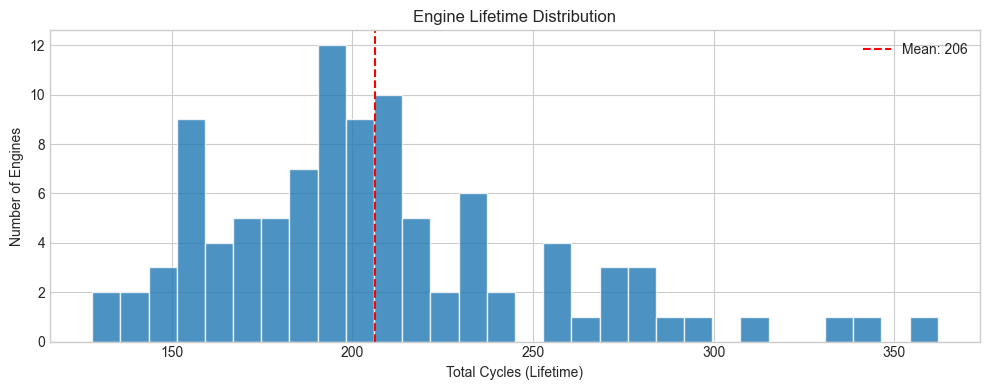

Shortest life: 128 cycles
Longest life: 362 cycles
Average life: 206.3 cycles


In [4]:
lifecycle = train_df.groupby('unit_id')['cycle'].max()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lifecycle, bins=30, edgecolor='white', alpha=0.8)
ax.set_xlabel('Total Cycles (Lifetime)')
ax.set_ylabel('Number of Engines')
ax.set_title('Engine Lifetime Distribution')
ax.axvline(lifecycle.mean(), color='red', linestyle='--', label=f'Mean: {lifecycle.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('../data/eda_lifecycle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Shortest life: {lifecycle.min()} cycles")
print(f"Longest life: {lifecycle.max()} cycles")
print(f"Average life: {lifecycle.mean():.1f} cycles")

# Sensor correlation heatmap:

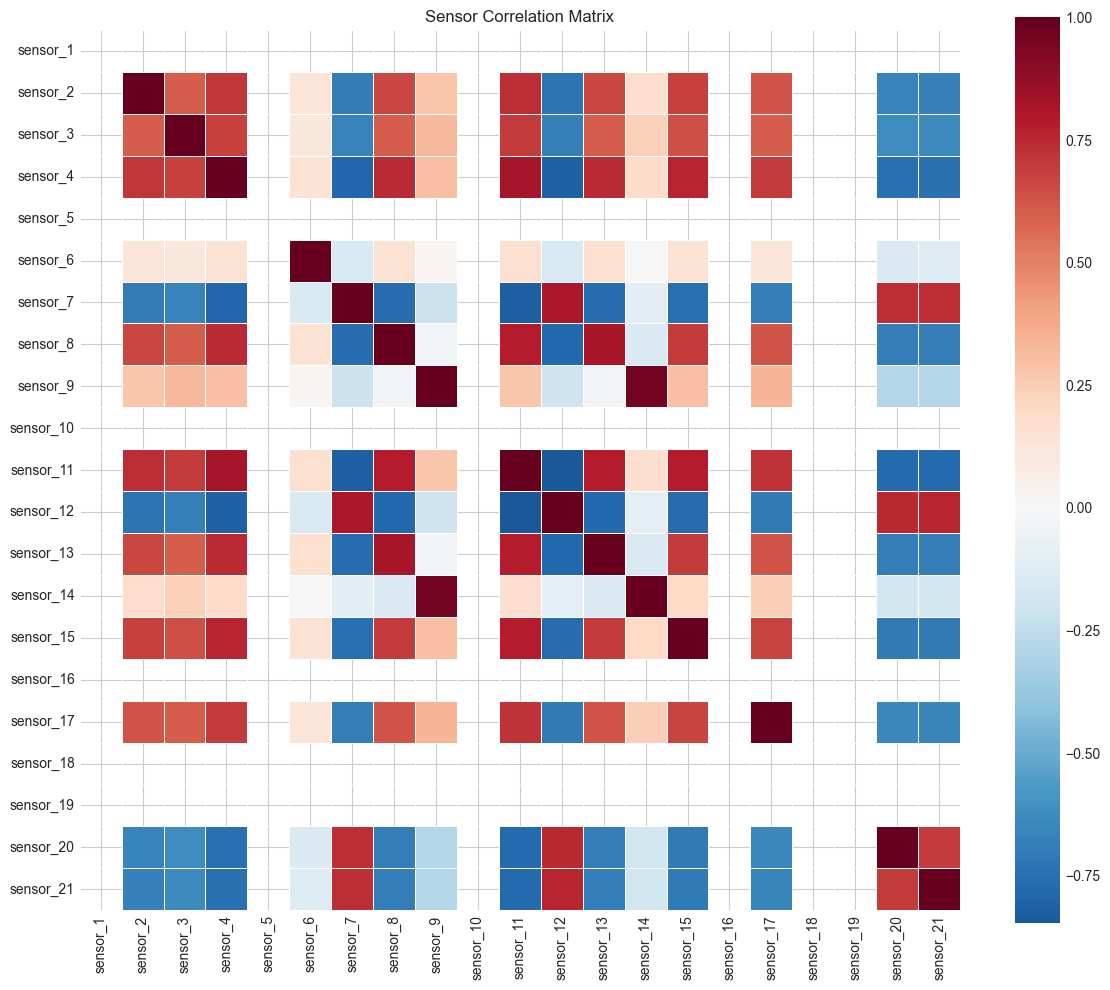

In [7]:
sensor_cols = get_sensor_columns(train_df)
corr = train_df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, ax=ax, fmt='.1f',
            annot=False, square=True, linewidths=0.5)
ax.set_title('Sensor Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Sensor variance (find constant/useless sensors):

In [8]:
variances = train_df[sensor_cols].var().sort_values(ascending=False)
print("Sensor variances:")
print(variances)
print(f"\nNear-zero variance sensors: {variances[variances < 1e-6].index.tolist()}")

Sensor variances:
sensor_9     4.876536e+02
sensor_14    3.639005e+02
sensor_4     8.101089e+01
sensor_3     3.759099e+01
sensor_17    2.398667e+00
sensor_7     7.833883e-01
sensor_12    5.439850e-01
sensor_2     2.500533e-01
sensor_11    7.133568e-02
sensor_20    3.266927e-02
sensor_21    1.171825e-02
sensor_13    5.172330e-03
sensor_8     5.038938e-03
sensor_15    1.406628e-03
sensor_6     1.929279e-06
sensor_5     2.840037e-29
sensor_16    1.203765e-35
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
dtype: float64

Near-zero variance sensors: ['sensor_5', 'sensor_16', 'sensor_1', 'sensor_10', 'sensor_19', 'sensor_18']


# Sensor trajectories for a single engine:

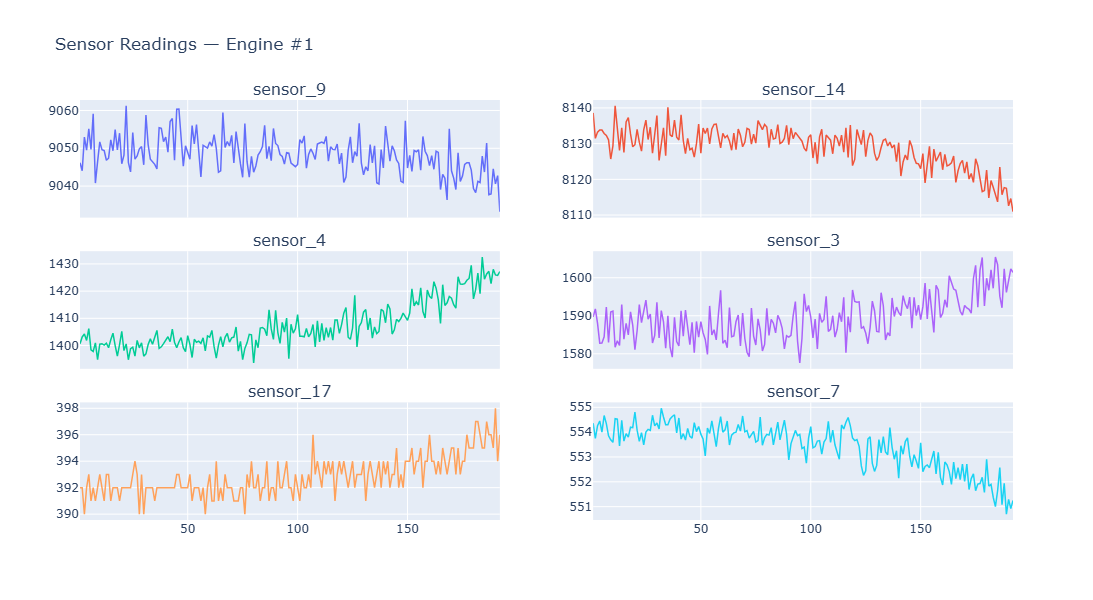

In [9]:
engine_1 = train_df[train_df['unit_id'] == 1].sort_values('cycle')

# Pick 6 sensors with highest variance
top_sensors = variances.head(6).index.tolist()

fig = make_subplots(rows=3, cols=2, subplot_titles=top_sensors,
                    shared_xaxes=True, vertical_spacing=0.08)

for i, sensor in enumerate(top_sensors):
    row, col = (i // 2) + 1, (i % 2) + 1
    fig.add_trace(
        go.Scatter(x=engine_1['cycle'], y=engine_1[sensor],
                   mode='lines', name=sensor,
                   line=dict(width=1.5)),
        row=row, col=col
    )

fig.update_layout(height=600, title_text='Sensor Readings — Engine #1',
                  showlegend=False)
fig.show()

# Anomaly class balance:

Normal: 17531 (85.0%)
Anomaly: 3100 (15.0%)


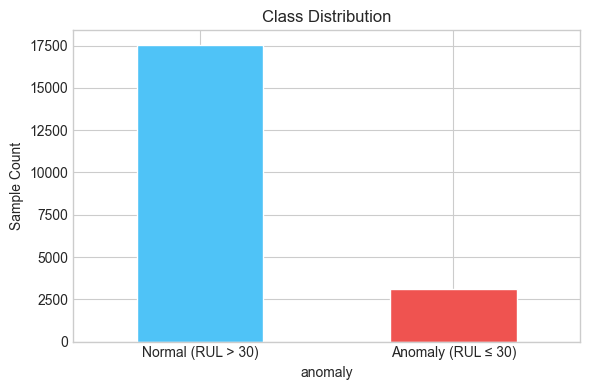

In [10]:
balance = train_df['anomaly'].value_counts()
print(f"Normal: {balance[0]} ({balance[0]/len(train_df):.1%})")
print(f"Anomaly: {balance[1]} ({balance[1]/len(train_df):.1%})")

fig, ax = plt.subplots(figsize=(6, 4))
balance.plot.bar(ax=ax, color=['#4fc3f7', '#ef5350'], edgecolor='white')
ax.set_xticklabels(['Normal (RUL > 30)', 'Anomaly (RUL ≤ 30)'], rotation=0)
ax.set_ylabel('Sample Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

# Key EDA findings (markdown cell):

## Key Findings

1. **Engine lifetimes** range from ~128 to ~362 cycles (mean ~206)
2. **Constant sensors** (near-zero variance): sensors 1, 5, 6, 10, 16, 18, 19 - these carry no degradation signal and should be removed
3. **High-signal sensors**: 2, 3, 4, 7, 8, 11, 12, 13, 15, 17, 20, 21 show clear degradation trends
4. **Class imbalance**: ~15% anomalous samples - will need AUC-PR as primary metric, not accuracy
5. **Degradation pattern**: Most sensors show exponential degradation in the final ~30 cycles